In [65]:
# Imports and Load data

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates


fed = pd.read_csv('../data/corpus/Fed.csv')
ecb = pd.read_csv('../data/corpus/ecb.csv')
boe = pd.read_csv('../data/corpus/boe.csv')

In [66]:
# Number of meetings

fed['n_words'] = fed['text'].str.split().str.len()
ecb['n_words'] = ecb['text'].str.split().str.len()
boe['n_words'] = boe['text'].str.split().str.len()

fed_grouped = fed.groupby(['date']).agg({'n_words': 'mean'}).reset_index(drop=False)
ecb_grouped = ecb.groupby(['date']).agg({'n_words': 'mean'}).reset_index(drop=False)
boe_grouped = boe.groupby(['date']).agg({'n_words': 'mean'}).reset_index(drop=False)

fed_grouped['date'] = pd.to_datetime(fed_grouped['date'], format='%Y%m%d')
ecb_grouped['date'] = pd.to_datetime(ecb_grouped['date'], format='%Y%m%d')
boe_grouped['date'] = pd.to_datetime(boe_grouped['date'], format='%Y%m%d')

print(f"FED: {len(fed_grouped)} meetings.")
print(f"ECB: {len(ecb_grouped)} meetings.")
print(f"BoE: {len(boe_grouped)} meetings.")

FED: 71 meetings.
ECB: 89 meetings.
BoE: 43 meetings.


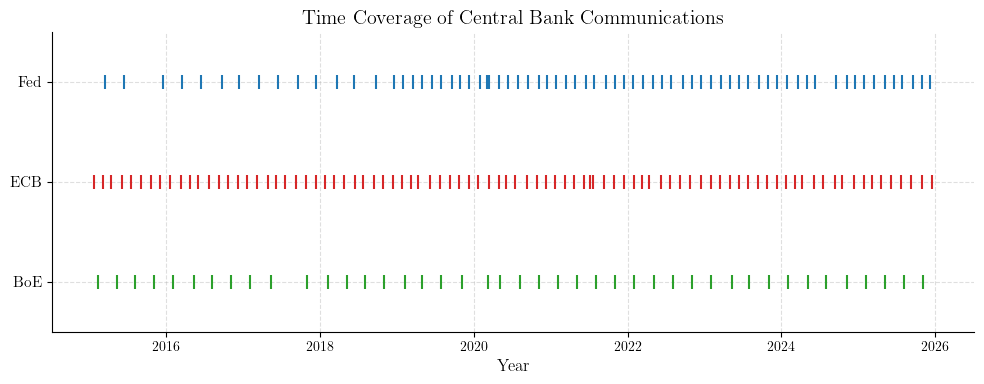

In [ ]:
# Time coverage

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "Times New Roman"],
    "mathtext.fontset": "cm",
    "axes.labelsize": 12,
    "font.size": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 11,
})

plt.figure(figsize=(10, 4))

plt.scatter(fed_grouped['date'], [3]*len(fed_grouped), color='#1f77b4', marker='|', s=100, zorder=100)
plt.scatter(ecb_grouped['date'], [2]*len(ecb_grouped), color='#d62728', marker='|', s=100, zorder=100)
plt.scatter(boe_grouped['date'], [1]*len(boe_grouped), color='#2ca02c', marker='|', s=100, zorder=100)

plt.yticks([1, 2, 3], ['BoE', 'ECB', 'Fed'])
plt.ylim(0.5, 3.5)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.grid(alpha=0.4, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xlabel('Year')
plt.title('Time Coverage of Central Bank Communications')

plt.tight_layout()
# plt.savefig('../../../../../time_coverage.png', dpi=800, bbox_inches='tight')
plt.show()

FED: 202.01
ECB: 293.5
BoE: 243.85


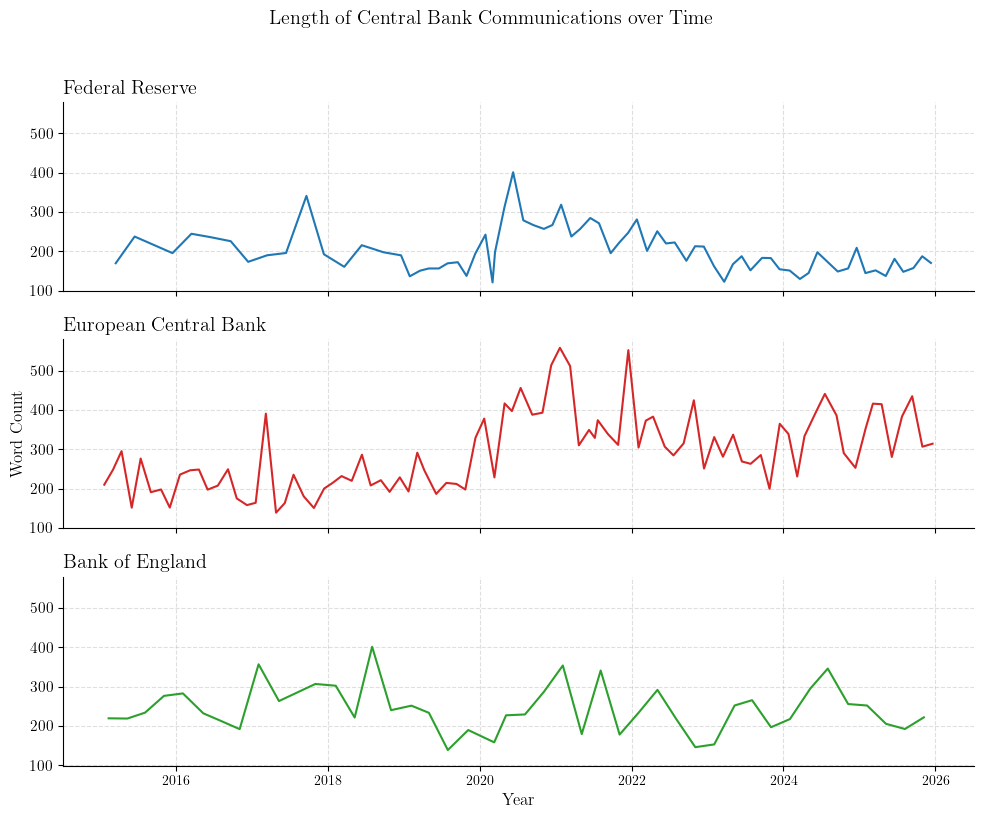

In [ ]:
# Average answer length

print(f"FED: {round(fed_grouped['n_words'].mean(),2)}")
print(f"ECB: {round(ecb_grouped['n_words'].mean(),2)}")
print(f"BoE: {round(boe_grouped['n_words'].mean(),2)}")

plt.rcParams.update({
    "text.usetex": True, 
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "Times New Roman"],
    "axes.labelsize": 12,
    "font.size": 12,
})

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True, sharey=True)

axes[0].plot(fed_grouped['date'], fed_grouped['n_words'], color='#1f77b4', linewidth=1.5)
axes[0].set_title('Federal Reserve', loc='left')

axes[1].plot(ecb_grouped['date'], ecb_grouped['n_words'], color='#d62728', linewidth=1.5)
axes[1].set_title('European Central Bank', loc='left')
axes[1].set_ylabel('Word Count')

axes[2].plot(boe_grouped['date'], boe_grouped['n_words'], color='#2ca02c', linewidth=1.5)
axes[2].set_title('Bank of England', loc='left')

axes[2].xaxis.set_major_locator(mdates.YearLocator(2)) 
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[2].set_xlabel('Year')

for ax in axes:
    ax.grid(alpha=0.4, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Length of Central Bank Communications over Time', y=1.02)
plt.tight_layout()
#plt.savefig('../../../../../appA_2.png', dpi=800, bbox_inches='tight') 
plt.show()

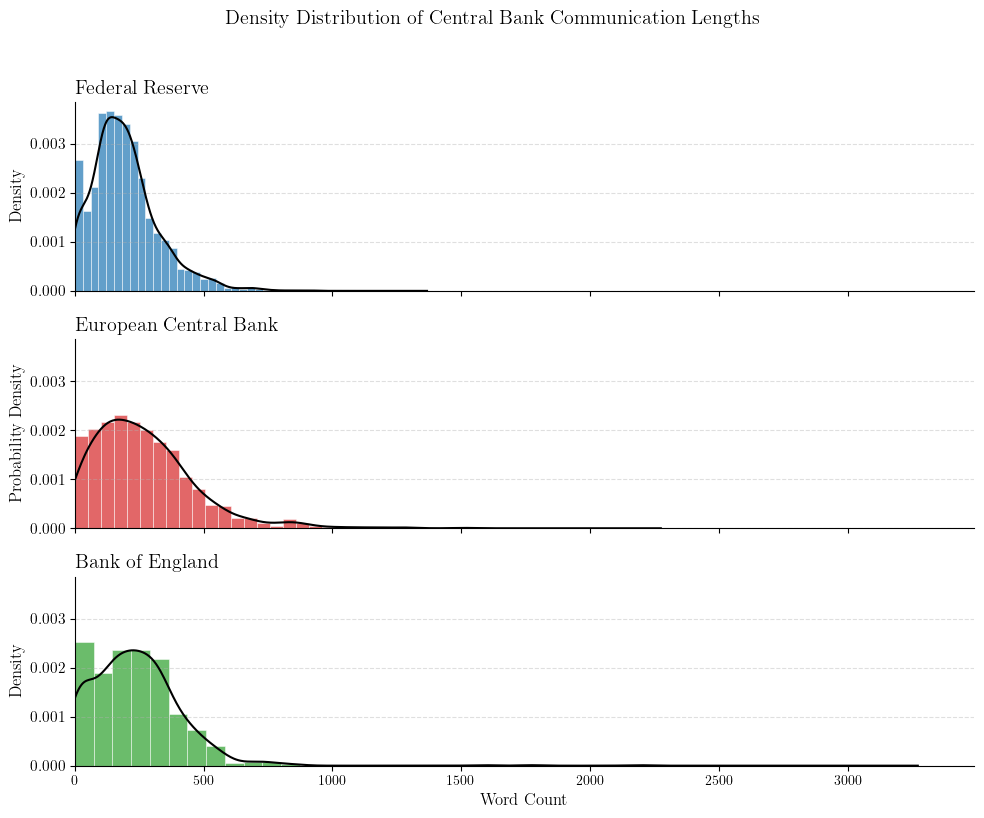

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Inject LaTeX-adjacent styling
plt.rcParams.update({
    "text.usetex": True, 
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "Times New Roman"],
    "axes.labelsize": 12,
    "font.size": 12,
})

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True, sharey=True)
common_bins = 30 

# FEDERAL RESERVE
axes[0].hist(fed['n_words'], bins=common_bins, density=True, color='#1f77b4', edgecolor='white', linewidth=0.5, alpha=0.7)
fed['n_words'].plot.kde(ax=axes[0], color='black', linewidth=1.5)
axes[0].set_title('Federal Reserve', loc='left')

# EUROPEAN CENTRAL BANK
axes[1].hist(ecb['n_words'], bins=common_bins, density=True, color='#d62728', edgecolor='white', linewidth=0.5, alpha=0.7)
ecb['n_words'].plot.kde(ax=axes[1], color='black', linewidth=1.5)
axes[1].set_title('European Central Bank', loc='left')
axes[1].set_ylabel('Probability Density')

# BANK OF ENGLAND
axes[2].hist(boe['n_words'], bins=common_bins, density=True, color='#2ca02c', edgecolor='white', linewidth=0.5, alpha=0.7)
boe['n_words'].plot.kde(ax=axes[2], color='black', linewidth=1.5)
axes[2].set_title('Bank of England', loc='left')
axes[2].set_xlabel('Word Count')

for ax in axes:
    ax.grid(alpha=0.4, linestyle='--', axis='y')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlim(left=0) 

plt.suptitle('Density Distribution of Central Bank Communication Lengths', y=1.02)
plt.tight_layout()
#plt.savefig('../../../../../appA_3.png', dpi=800, bbox_inches='tight') 
plt.show()